In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [16]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:

def running_percentiles(xdata, ydata, window_size, percentiles=[50], dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>0]))/dx)
    
    
    bin_first = min(xdata[xdata>0]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                running_percentile_arr[ip][i] = np.percentile(ydata[bin_mask], q=percentile)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_percentile_arr



In [4]:
dir1 = "/cosma7/data/dp004/dc-zhan5/eagle-sfr/mvir/snap17"

In [81]:
ihalo_group, mvir_group, group_sfrs_eagle = np.loadtxt(f"{dir1}/group_sfrs.txt", unpack=True)

In [82]:
ihalo_cent, mvir_cent, cent_sfrs_eagle = np.loadtxt(f"{dir1}/cent_sfrs.txt", unpack=True)

In [56]:
mvir_sat, sat_sfrs_eagle = np.loadtxt(f"{dir1}/sum_sat_sfrs.txt", unpack=True)

In [84]:
ihalo_group[0]-17000000000000

0.0

In [85]:
index0 = 17000000000000

In [88]:
ihalo_cent

array([1.70000e+13, 1.70000e+13, 1.70000e+13, ..., 1.70073e+13,
       1.70077e+13, 1.70077e+13])

In [91]:
ihalo_cent.astype(int)-index0

array([         0,          1,          2, ..., 7300007527, 7700004736,
       7700008723])

In [93]:
in_subset = np.isin(ihalo_group, ihalo_cent)

In [111]:
cent_sfrs_eagle1 = np.zeros(len(group_sfrs_eagle))
cent_sfrs_eagle1[in_subset] = 10**cent_sfrs_eagle

In [112]:
group_sfrs_eagle1 = 10**group_sfrs_eagle

In [42]:
percentiles_list = [10, 25, 50, 75, 90]
window_size=0.2
dlogM= 0.1

In [46]:
bin_cents_cent_eagle, percentiles_cent_eagle = running_percentiles(mvir_cent, cent_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_sat_eagle, percentiles_sat_eagle = running_percentiles(mvir_sat, sat_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_group_eagle, percentiles_group_eagle = running_percentiles(mvir_group, group_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)


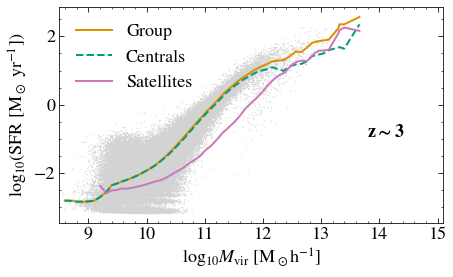

<Figure size 480x288 with 0 Axes>

In [20]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir_group, group_sfrs, s=0.1, color="lightgrey", label="Group")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
        plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
    elif i == 1 or i == 3:
        
        alpha = 0.5
        #plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Group")
group = Line2D([],[], linestyle="solid", color=color_list[0], label="Group")
cent = Line2D([],[], linestyle="dashed", color=color_list[1], label="Centrals")
sat_leg = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellites")
plt.legend(handles=[group, cent, sat_leg], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 15.1)
"""
frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

# plt.plot(bin_cents_frac_group, 1-group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
# plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
# plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites", color=color_list[2])

plt.plot(bin_cents_frac_group, group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
plt.plot(bin_cents_frac_cent, cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
plt.plot(bin_cents_frac_sat, sat_frac, label="Satellites", color=color_list[2])
plt.ylabel("Frac. with \n SFR > SFR$_{\mathrm{min}}$")
"""
plt.xlabel(r"log$_{10}$$ M_{\rm vir}$ [M$_\odot$h$^{-1}$]")
#plt.ylabel("Frac. with \n logSFR > -2")

ax = plt.gca()
ax.annotate("$\mathbf{z \sim 3}$", (0.9,0.4), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("../figures/sfr-mvir_median_z3.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

In [21]:
snapnum = 40

In [22]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-1'

In [23]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [24]:
h = 0.6774

In [57]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [58]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [59]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [60]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [61]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [62]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [63]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [64]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [65]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [66]:
bin_cents_cent, percentiles_cent = running_percentiles(mvir, cent_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_sat, percentiles_sat = running_percentiles(mvir, sum_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_group, percentiles_group = running_percentiles(mvir, group_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


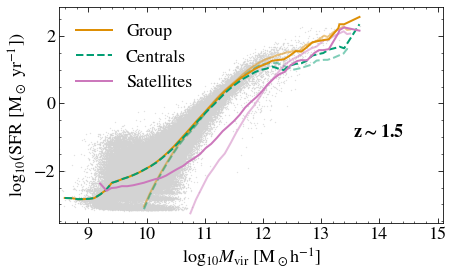

<Figure size 480x288 with 0 Axes>

In [69]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir_group, group_sfrs_eagle, s=0.1, color="lightgrey", label="Group")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 0.5
        plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)
        
        alpha=1
        plt.plot(bin_cents_group_eagle, percentiles_group_eagle[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_cent_eagle, percentiles_cent_eagle[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        plt.plot(bin_cents_sat_eagle, percentiles_sat_eagle[i], color=color_list[2],alpha = alpha)

    
    elif i == 1 or i == 3:
        
        alpha = 0.5
        #plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
        #plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Group")
group = Line2D([],[], linestyle="solid", color=color_list[0], label="Group")
cent = Line2D([],[], linestyle="dashed", color=color_list[1], label="Centrals")
sat_leg = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellites")
plt.legend(handles=[group, cent, sat_leg], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 15.1)
"""
frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

# plt.plot(bin_cents_frac_group, 1-group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
# plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
# plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites", color=color_list[2])

plt.plot(bin_cents_frac_group, group_frac, label="Group", color=color_list[0]) # 1 minus to get fraction greater than sfr lim
plt.plot(bin_cents_frac_cent, cent_frac, label="Centrals", linestyle="dashed", color=color_list[1])
plt.plot(bin_cents_frac_sat, sat_frac, label="Satellites", color=color_list[2])
plt.ylabel("Frac. with \n SFR > SFR$_{\mathrm{min}}$")
"""
plt.xlabel(r"log$_{10}$$ M_{\rm vir}$ [M$_\odot$h$^{-1}$]")
#plt.ylabel("Frac. with \n logSFR > -2")

ax = plt.gca()
ax.annotate("$\mathbf{z \sim 1.5}$", (0.9,0.4), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("../figures/sfr-mvir_median_z3.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

In [104]:
def get_percentiles(data, mvir):
    dlogM = 0.1
    mhalo_bins = np.arange(10,14.5, dlogM)
    
    median_list = []
    percentiles = [25, 50, 75]
    nbins = len(mhalo_bins)
    percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros(nbins, dtype=float)
    for i, m in enumerate(mhalo_bins):
        bin_mask = (mvir > m) & (mvir < m+dlogM)
        cfrac = data[bin_mask]
        median = np.nanmedian(cfrac)

        median_list.append(median)

        for ip, percentile in enumerate(percentiles):
            percentile_arr[ip][i] = np.nanpercentile(cfrac, q=percentile)

        bin_cents[i] = np.median(mvir[bin_mask])
    return mhalo_bins, percentile_arr

In [113]:
cent_frac_eagle = cent_sfrs_eagle1/(group_sfrs_eagle1)

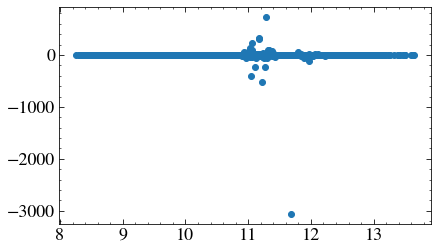

In [125]:
plt.scatter(mvir, cent_frac)

In [126]:
cent_frac = 10**cent_sfrs/(10**group_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [122]:
mhalo_bins, frac_percent_eagle = get_percentiles(cent_frac_eagle, mvir=mvir_group)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [127]:
mhalo_bins, frac_percent = get_percentiles(cent_frac, mvir=mvir)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)


[<matplotlib.lines.Line2D object at 0x7fc37c872240>, <matplotlib.lines.Line2D object at 0x7fc37c8722e8>, <matplotlib.lines.Line2D object at 0x7fc37c872550>]


Text(0, 0.5, 'Fraction')

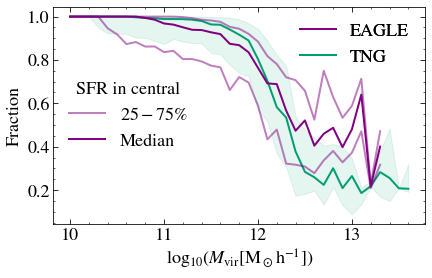

In [164]:
fig, ax1 = plt.subplots()

ax1.fill_between(mhalo_bins, frac_percent[0], frac_percent[2], alpha=0.1, color=palette_tab10[2])
ax1.plot(mhalo_bins, frac_percent[1], alpha=1, color=palette_tab10[2])
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax1.plot(mhalo_bins, frac_percent_eagle[i], alpha=alpha, color="purple", linestyle="solid", label=label)
    #ax1.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
h, l = ax1.get_legend_handles_labels()
print(h)
leg = ax1.legend(handles=h[:2], labels=["$25-75 \%$", "Median"], loc="center left", title="SFR in central")
ax1.add_artist(leg)
# for i, p in enumerate(bh_frac):
#     if i == 1:
#         alpha = 1
#         label = "Median"
#     else:
#         alpha = 0.5
#         label="25th-75th percentile"
#     ax2.plot(mhalo_bins, (p), alpha=alpha, color="grey")
#ax1.plot(mhalo_bins, bh_frac, alpha=alpha, color="grey", label = "logM$_{\mathrm{BH}}$ > 8" )
#plt.legend(loc="upper right", bbox_to_anchor=(1,0.9))

eag = Line2D([],[],color="purple", linestyle="solid", label="EAGLE")
tng = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="TNG")


leg = ax1.legend(handles=[eag, tng], loc="upper right")
ax1.add_artist(leg)

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
ax1.set_ylabel("Fraction")

#ax2.set_ylabel(r"Fraction with $\rm log_{10} $$M_{\mathrm{BH}}$ > 8")
#ax = plt.gca()
#ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac_w_bh.pdf", format="pdf", bbox_inches="tight")

[<matplotlib.lines.Line2D object at 0x7fc37c0dae10>, <matplotlib.lines.Line2D object at 0x7fc37c0dab70>, <matplotlib.lines.Line2D object at 0x7fc37c0da400>]


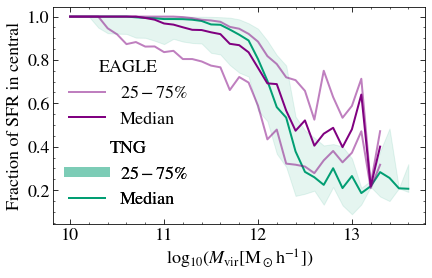

In [178]:
fig, ax1 = plt.subplots()

ax1.fill_between(mhalo_bins, frac_percent[0], frac_percent[2], alpha=0.1, color=palette_tab10[2])
ax1.plot(mhalo_bins, frac_percent[1], alpha=1, color=palette_tab10[2])
for i, p in enumerate(frac_percent):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    ax1.plot(mhalo_bins, frac_percent_eagle[i], alpha=alpha, color="purple", linestyle="solid", label=label)
    #ax1.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])
h, l = ax1.get_legend_handles_labels()
print(h)
leg = ax1.legend(handles=h[:2], labels=["$25-75 \%$", "Median"], loc="center left", title="EAGLE", bbox_to_anchor=(0,0.6))
ax1.add_artist(leg)
tng_light = Line2D([],[],color=palette_tab10[2], alpha=0.3, linestyle="solid", label="$25-75 \%$", linewidth=10)
tng_dark = Line2D([],[],color=palette_tab10[2], alpha=1, linestyle="solid", label="Median")
leg = ax1.legend(handles=[tng_light, tng_dark], loc="lower left", title="TNG")
ax1.add_artist(leg)
# for i, p in enumerate(bh_frac):
#     if i == 1:
#         alpha = 1
#         label = "Median"
#     else:
#         alpha = 0.5
#         label="25th-75th percentile"
#     ax2.plot(mhalo_bins, (p), alpha=alpha, color="grey")
#ax1.plot(mhalo_bins, bh_frac, alpha=alpha, color="grey", label = "logM$_{\mathrm{BH}}$ > 8" )
#plt.legend(loc="upper right", bbox_to_anchor=(1,0.9))

# eag = Line2D([],[],color="purple", linestyle="solid", label="EAGLE")
# tng = Line2D([],[],color=palette_tab10[2], linestyle="solid", label="TNG")


# leg = ax1.legend(handles=[eag, tng], loc="upper right")
# ax1.add_artist(leg)

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
ax1.set_ylabel("Fraction of SFR in central")

#ax2.set_ylabel(r"Fraction with $\rm log_{10} $$M_{\mathrm{BH}}$ > 8")
#ax = plt.gca()
#ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac_eagle.pdf", format="pdf", bbox_inches="tight")